In [1]:
# ============================================================
# 1. 라이브러리 불러오기
# ============================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

# 한글 깨짐 방지 (Windows 기준)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [5]:
# ============================================================
# 2. 데이터 불러오기
# ============================================================
df = pd.read_csv("../data/processed/train_df_2020_2025.csv")

print("shape:", df.shape)
display(df.head())
print(df.columns.tolist())

shape: (41299, 14)


,pid,year_t0,year_t1,telco_t0,telco_t1,churn_any,churn_to_mvno,a03002_tminus1,a03024_tminus1,a03026_tminus1,c01002_tminus1,c01004_tminus1,c02003_tminus1,c02001_tminus1
0,1000001,2020,2021,2.0,1.0,1,0,2.0,0.0,0.0,4.0,1.0,1.0,1.0
1,1000001,2021,2022,1.0,1.0,0,0,2.0,1.0,0.0,5.0,1.0,1.0,1.0
2,1000001,2022,2023,1.0,1.0,0,0,3.0,1.0,0.0,6.0,2.0,1.0,1.0
3,1000001,2023,2024,1.0,1.0,0,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0
4,1000001,2024,2025,1.0,3.0,1,0,3.0,1.0,1.0,5.0,1.0,1.0,1.0


['pid', 'year_t0', 'year_t1', 'telco_t0', 'telco_t1', 'churn_any', 'churn_to_mvno', 'a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1']


In [6]:
# ============================================================
# 3. 컬럼 구성 확인
# ============================================================
# 예측에 쓰지 않을 컬럼
# - pid: 그룹 분리용
# - year_t0, year_t1: 식별/시점 정보
# - telco_t0, telco_t1: 라벨 생성에 직접 연결될 수 있어 기본 baseline에서는 제외 권장
# - churn_to_mvno: 다른 타깃
# - churn_any: 현재 타깃

target_col = "churn_any"
group_col = "pid"

drop_cols = [
    "pid",
    "year_t0",
    "year_t1",
    "churn_any",
    "churn_to_mvno"
]

# 혹시 telco 관련 컬럼이 있으면 baseline에서는 제외
possible_leakage_cols = [col for col in df.columns if "telco" in col.lower()]
drop_cols += possible_leakage_cols

drop_cols = list(dict.fromkeys(drop_cols))  # 중복 제거

feature_cols = [col for col in df.columns if col not in drop_cols]

print("사용할 feature 개수:", len(feature_cols))
print("feature_cols:", feature_cols)

사용할 feature 개수: 7
feature_cols: ['a03002_tminus1', 'a03024_tminus1', 'a03026_tminus1', 'c01002_tminus1', 'c01004_tminus1', 'c02003_tminus1', 'c02001_tminus1']


In [7]:
# ============================================================
# 4. X, y, groups 분리
# ============================================================
X = df[feature_cols].copy()
y = df[target_col].copy()
groups = df[group_col].copy()

print("X shape:", X.shape)
print("y mean:", y.mean())
print("고유 pid 수:", groups.nunique())

X shape: (41299, 7)
y mean: 0.36276907431172667
고유 pid 수: 10071


In [8]:
# ============================================================
# 5. pid 기준 train / test 분리
# ============================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train churn rate:", y_train.mean())
print("Test churn rate :", y_test.mean())
print("Train pid 수:", groups_train.nunique())
print("Test pid 수 :", groups_test.nunique())
print("겹치는 pid 수:", len(set(groups_train).intersection(set(groups_test))))

Train shape: (32992, 7)
Test shape : (8307, 7)
Train churn rate: 0.36520974781765275
Test churn rate : 0.3530757192729024
Train pid 수: 8056
Test pid 수 : 2015
겹치는 pid 수: 0


In [9]:
# ============================================================
# 6. Logistic Regression 파이프라인
# ============================================================
logistic_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

logistic_pipe.fit(X_train, y_train)

y_pred_log = logistic_pipe.predict(X_test)
y_proba_log = logistic_pipe.predict_proba(X_test)[:, 1]

In [10]:
# ============================================================
# 7. Random Forest 학습
# ============================================================
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)

y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

In [11]:
# ============================================================
# 8. 평가 함수
# ============================================================
def evaluate_binary_classifier(y_true, y_pred, y_proba, model_name="model"):
    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba)
    }
    return result

result_log = evaluate_binary_classifier(y_test, y_pred_log, y_proba_log, "LogisticRegression")
result_rf = evaluate_binary_classifier(y_test, y_pred_rf, y_proba_rf, "RandomForest")

result_df = pd.DataFrame([result_log, result_rf]).sort_values("pr_auc", ascending=False)
display(result_df)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
1,RandomForest,0.532443,0.396247,0.619161,0.483236,0.576294,0.409261
0,LogisticRegression,0.526303,0.378457,0.531879,0.442240,0.533407,0.375832


In [12]:
# ============================================================
# 9. 상세 리포트 출력
# ============================================================
print("===== Logistic Regression =====")
print(classification_report(y_test, y_pred_log, digits=4))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_log))

print("\n===== Random Forest =====")
print(classification_report(y_test, y_pred_rf, digits=4))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

===== Logistic Regression =====
              precision    recall  f1-score   support

           0     0.6719    0.5233    0.5883      5374
           1     0.3785    0.5319    0.4422      2933

    accuracy                         0.5263      8307
   macro avg     0.5252    0.5276    0.5153      8307
weighted avg     0.5683    0.5263    0.5368      8307

Confusion Matrix
[[2812 2562]
 [1373 1560]]

===== Random Forest =====
              precision    recall  f1-score   support

           0     0.7001    0.4851    0.5731      5374
           1     0.3962    0.6192    0.4832      2933

    accuracy                         0.5324      8307
   macro avg     0.5482    0.5521    0.5282      8307
weighted avg     0.5928    0.5324    0.5414      8307

Confusion Matrix
[[2607 2767]
 [1117 1816]]


In [13]:
# ============================================================
# 10. Logistic Regression 계수 해석
# ============================================================
log_model = logistic_pipe.named_steps["model"]

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": log_model.coef_[0]
})

coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

display(coef_df.head(15))

,feature,coef,abs_coef
0,a03002_tminus1,0.089276,0.089276
2,a03026_tminus1,-0.071649,0.071649
4,c01004_tminus1,-0.053255,0.053255
5,c02003_tminus1,-0.051466,0.051466
6,c02001_tminus1,-0.044400,0.044400
3,c01002_tminus1,0.027522,0.027522
1,a03024_tminus1,-0.009005,0.009005


In [14]:
# ============================================================
# 11. Random Forest 중요도 해석
# ============================================================
rf_model = rf_pipe.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df.head(15))

,feature,importance
3,c01002_tminus1,0.397918
4,c01004_tminus1,0.218428
0,a03002_tminus1,0.157579
6,c02001_tminus1,0.073108
2,a03026_tminus1,0.052961
5,c02003_tminus1,0.051762
1,a03024_tminus1,0.048244


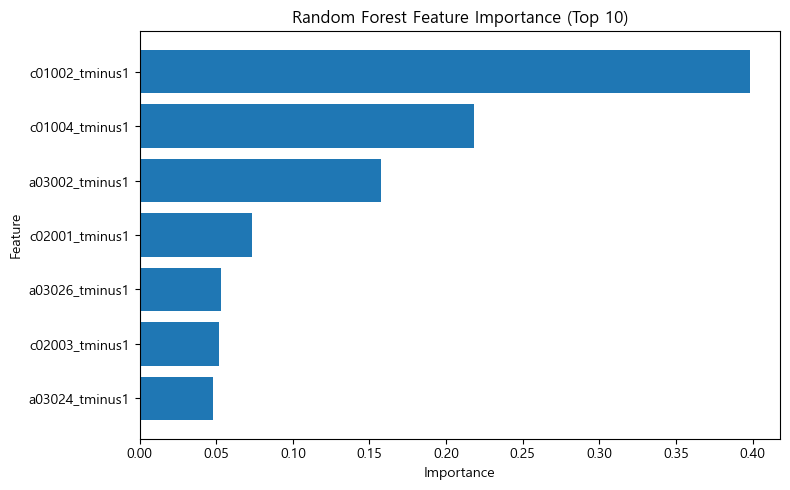

In [15]:
# ============================================================
# 12. 중요 변수 시각화
# ============================================================
top_n = 10

plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["feature"].head(top_n)[::-1],
    importance_df["importance"].head(top_n)[::-1]
)
plt.title("Random Forest Feature Importance (Top 10)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## [ 결과 해석 ]

### 1. `churn_any` 예측 결과 해석

`churn_any`는 전년 대비 통신사가 변경되었는지를 예측하는 문제로, 이번 데이터에서는 양성 비율이 약 36.3% 수준으로 확인되었다.
이는 `churn_to_mvno`에 비하면 극단적인 불균형은 아니지만, 여전히 단순 정확도만으로 성능을 판단하기에는 한계가 있다.
따라서 이번 실험에서는 Accuracy뿐 아니라 `F1`, `ROC-AUC`, `PR-AUC`, `Recall`을 함께 해석하는 것이 적절하다.

baseline 비교 결과에서는 `RandomForest`가 `LogisticRegression`보다 전반적으로 더 나은 성능을 보였다.
특히 `Recall`, `F1`, `ROC-AUC`, `PR-AUC`에서 모두 더 높은 값을 기록해, 실제 이탈자를 탐지하는 성능이 더 우수한 것으로 나타났다.

즉, 이번 `churn_any` 예측에서는 단순한 선형 관계를 가정하는 `LogisticRegression`보다, 변수 간 비선형 패턴을 반영할 수 있는 `RandomForest`가 더 적합한 baseline 모델로 해석할 수 있다.
이는 통신사 변경 여부가 단순한 선형 관계만으로 설명되기보다, 여러 변수의 복합적이고 비선형적인 패턴을 포함하고 있을 가능성을 시사한다.

---

### 2. 모델별 성능 비교

`RandomForest`는 `LogisticRegression`보다 더 높은 `Recall`과 `F1`을 보였다.
이는 실제 이탈자를 더 많이 찾아내면서도, 전체 분류 균형 측면에서도 더 나은 결과를 보였다는 뜻이다.
또한 `PR-AUC` 역시 더 높게 나타나, 이탈 고객 탐지 성능 측면에서 기준 모델로 삼기에 더 적절한 결과를 보였다.

반면 `LogisticRegression`은 전체적으로 모든 주요 지표에서 `RandomForest`보다 낮은 값을 보였다.
특히 `Recall`과 `PR-AUC` 차이가 비교적 분명하게 나타나, 실제 이탈자 포착 성능에서 한계가 있었다고 볼 수 있다.

즉, 이번 결과에서는 `RandomForest`가 보다 많은 이탈자를 탐지했고, 예측 성능의 전반적인 균형도 더 우수한 것으로 해석된다.

---

### 3. Confusion Matrix 해석

`RandomForest`는 실제 이탈자를 `LogisticRegression`보다 더 많이 맞췄다.
이는 Recall이 더 높게 나타난 결과와도 일치한다.
즉, 이탈 가능성이 있는 고객을 보다 적극적으로 탐지하는 방향으로 작동했다고 볼 수 있다.

다만 그만큼 비이탈자를 이탈자로 잘못 예측한 사례도 적지 않게 나타났다.
즉, 이탈자를 더 많이 찾는 대신 오탐(False Positive)도 함께 증가한 구조다.
이는 모델이 실제 이탈자를 더 많이 찾아내는 데는 유리했지만, 이탈하지 않을 고객까지 이탈 위험군으로 예측한 경우도 적지 않았다는 뜻이다.
따라서 현재 모델은 이탈자를 놓치지 않는 데는 비교적 유리하지만, 위험 고객을 정밀하게 선별하는 측면에서는 한계가 있다.

반면 `LogisticRegression`은 상대적으로 더 보수적인 예측을 수행했고, 그 결과 이탈자 탐지 성능이 낮아졌다.
즉, 전체적으로는 단순한 기준 모델 역할은 가능하지만, 실제 이탈자 탐지 목적에서는 `RandomForest`보다 제한적인 성능을 보였다.

---

### 4. 변수 중요도 해석

`LogisticRegression`에서는 `a03002_tminus1`, `a03026_tminus1`, `c01004_tminus1`, `c02003_tminus1`, `c02001_tminus1` 등이 상대적으로 큰 계수를 보였다.
이는 해당 변수들이 이탈 여부를 설명하는 데 일정한 방향성을 가진 신호로 작용했을 가능성을 보여준다.

`RandomForest`에서는 `c01002_tminus1`, `c01004_tminus1`, `a03002_tminus1`가 가장 중요한 변수로 나타났다.
특히 `c01002_tminus1`의 중요도가 가장 높게 나타나, 현재 baseline 기준에서는 이 변수가 이탈 여부를 구분하는 데 가장 큰 역할을 한 것으로 볼 수 있다.

즉, 두 모델을 종합하면 `c01002_tminus1`, `c01004_tminus1`, `a03002_tminus1`이 공통적으로 중요한 변수군으로 해석할 수 있다.
이 변수들은 이후 추가 분석이나 모델 개선 단계에서도 우선적으로 살펴볼 필요가 있다.

다만 현재 단계의 변수 중요도는 예측 성능에 대한 상대적 기여를 의미할 뿐이며, 이를 직접적인 원인 변수로 해석하기에는 한계가 있다.
따라서 현 단계에서는 예측에 유용한 신호를 제공한 변수로 이해하는 것이 적절하다.

---

### 5. 종합 정리

이번 `churn_any` baseline 실험에서는 `RandomForest`가 `LogisticRegression`보다 전반적으로 우수한 성능을 보였다.
특히 실제 이탈자를 더 많이 탐지했고, `F1`, `ROC-AUC`, `PR-AUC`에서도 더 높은 값을 기록해 기준 모델로서 더 적절한 결과를 나타냈다.

다만 Precision은 여전히 높지 않아, 이탈자로 예측한 고객 중 실제 이탈자가 아닌 사례도 적지 않았다.
즉, 실제 이탈자를 더 많이 잡아낼 수는 있었지만, 이탈하지 않을 고객까지 위험군으로 포함되는 경우도 적지 않았다는 뜻이다.
따라서 현재 결과는 이탈 탐지 가능성은 확인되었지만, 오탐을 줄이고 예측의 정밀도를 높이기 위한 추가 개선이 필요한 상태라고 볼 수 있다.

결과적으로 이번 baseline은 `churn_any` 예측에서 비선형 패턴을 반영하는 모델이 더 유리할 가능성을 보여주었으며, 이후 단계에서는 교차검증, threshold 조정, feature 확장 등을 통해 성능을 더욱 개선할 필요가 있다.

---

## [ 요약 ]

> `churn_any` baseline 비교 결과, `RandomForest`가 `LogisticRegression`보다 더 높은 `Recall`, `F1`, `ROC-AUC`, `PR-AUC`를 보여 전반적으로 더 우수한 성능을 나타냈다.

> 이는 실제 이탈자를 더 많이 탐지했다는 점에서 의미가 있으며, 현재 기준에서는 `RandomForest`가 `churn_any` 예측의 기준 모델로 더 적절하다고 해석할 수 있다.

> 다만 Precision은 여전히 높지 않아 이탈하지 않을 고객까지 위험군으로 예측하는 경우가 적지 않았으며, 향후에는 threshold 조정과 feature 확장을 통해 예측의 정밀도를 높일 필요가 있다.